In [5]:
# This is the Data cleaning file

#importing all libraries

import pandas as pd      #  for data manipulation 
import numpy as np       # For numerical operations, especially with missing values 



# Load the dataset
file_path = "cleaned_full_personal_finance.csv"
df = pd.read_csv(file_path)

#Understanding the DATA
# --- Phase 1: Initial Setup  ---

# Step 1.1: Initial Inspection 
print("\n--- Initial Inspection of Loaded Data ---")
print("DataFrame Info:")
df.info() # Gets a summary of the DataFrame, including column names, non-null counts, and data types

print("\nFirst 5 rows of the DataFrame:")
print(df.head()) # Display the first 5 rows to see the data structure and values



--- Initial Inspection of Loaded Data ---
DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101000 entries, 0 to 100999
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Date                       101000 non-null  object 
 1   Description                101000 non-null  object 
 2   Category                   101000 non-null  object 
 3   Amount                     101000 non-null  float64
 4   Type                       101000 non-null  object 
 5   Notes                      101000 non-null  object 
 6   Merchant                   95958 non-null   object 
 7   Payment Method             95948 non-null   object 
 8   Balance After Transaction  101000 non-null  float64
 9   Currency                   101000 non-null  object 
 10  Transaction ID             101000 non-null  object 
 11  Account Type               101000 non-null  object 
 12  Transaction Type           

In [6]:

# --- Data Statistics: Mean, Median, Mode ---
print("--- Statistics for 'Amount' (Numerical) ---")
print(f"Mean Amount: {df['Amount'].mean():.2f}")
print(f"Median Amount: {df['Amount'].median():.2f}")
print("Mode Amount(s):")
print(df['Amount'].mode()) 

print("\n" + "="*50 + "\n")

print("--- Statistics for 'Merchant' (Categorical) ---")
print("Most Frequent Merchant(s) (Mode):")
print(df['Merchant'].mode())
print("\nTop 10 Merchants by Frequency:")

df['Merchant'].value_counts().head(10)





--- Statistics for 'Amount' (Numerical) ---
Mean Amount: 386.11
Median Amount: 345.06
Mode Amount(s):
0    10.722772
Name: Amount, dtype: float64


--- Statistics for 'Merchant' (Categorical) ---
Most Frequent Merchant(s) (Mode):
0    Netflix
Name: Merchant, dtype: object

Top 10 Merchants by Frequency:


Merchant
Netflix      12023
Amazon       12021
Spotify      12018
Target       12015
Walmart      12007
Lyft         11989
McDonalds    11984
Uber         11901
Name: count, dtype: int64

In [7]:
print("--- Statistics for 'Payment Method' (Categorical) ---")
print("Most Frequent Payment Method(s) (Mode):")
print(df['Payment Method'].mode())
print("\nTop 5 Payment Methods by Frequency:")

df['Payment Method'].value_counts().head(5)

--- Statistics for 'Payment Method' (Categorical) ---
Most Frequent Payment Method(s) (Mode):
0    Credit Card
Name: Payment Method, dtype: object

Top 5 Payment Methods by Frequency:


Payment Method
Credit Card       19304
Debit Card        19239
Bank Transfer     19161
Cash              19146
Mobile Payment    19098
Name: count, dtype: int64

In [8]:
# --- Statistics for 'Location' (Categorical) ---

print("--- Statistics for 'Location' ---")

# Most Frequent Location(s) (Mode)
print("Most Frequent Location(s) (Mode):")
print(df['Location'].mode()) # Returns the location(s) that appear most often

print("\nTop 10 Locations by Frequency:")
# Value counts show the frequency of each unique location
# .head(10) limits it to the top 10 most common locations
df['Location'].value_counts().head(10)

--- Statistics for 'Location' ---
Most Frequent Location(s) (Mode):
0    Lake Mark
Name: Location, dtype: object

Top 10 Locations by Frequency:


Location
Lake Mark             2018
Port Audreyside       1988
Hullport              1985
Port Heidi            1979
West Chloefort        1974
Michaelburgh          1963
Lake Brittany         1960
Barbaraport           1959
New Tannerville       1958
Port Gabriellafort    1955
Name: count, dtype: int64

In [ ]:


# ---  Data Cleaning: Convert 'Time' and Extract 'Hour_Of_Day' ---

# First, ensuring 'Time' column is string type and handle any potential non-string values
df['Time'] = df['Time'].astype(str)

# Extract hour directly from string for robustness 
#  use regex to grab the first two digits only such as 06: or 12:
df['Hour_Of_Day'] = df['Time'].str.extract(r'^(\d{2}):', expand=False).astype(float)



print("\n--- After  'Hour_Of_Day' extraction ---")
df.info() 

print("\nFirst 5 rows with 'Time' and 'Hour_Of_Day':")
print(df[['Time', 'Hour_Of_Day', 'Location']].head())

# Check for any NaNs in Hour_Of_Day
print("\nNulls in Hour_Of_Day after extraction:")
print(df['Hour_Of_Day'].isnull().sum())


--- After  'Hour_Of_Day' extraction ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101000 entries, 0 to 100999
Data columns (total 19 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Date                       101000 non-null  object 
 1   Description                101000 non-null  object 
 2   Category                   101000 non-null  object 
 3   Amount                     101000 non-null  float64
 4   Type                       101000 non-null  object 
 5   Notes                      101000 non-null  object 
 6   Merchant                   95958 non-null   object 
 7   Payment Method             95948 non-null   object 
 8   Balance After Transaction  101000 non-null  float64
 9   Currency                   101000 non-null  object 
 10  Transaction ID             101000 non-null  object 
 11  Account Type               101000 non-null  object 
 12  Transaction Type           101000 non-null  o


--- Top 10 Most Frequent Locations ---
Location
Lake Mark             2018
Port Audreyside       1988
Hullport              1985
Port Heidi            1979
West Chloefort        1974
Michaelburgh          1963
Lake Brittany         1960
Barbaraport           1959
New Tannerville       1958
Port Gabriellafort    1955
Name: count, dtype: int64



--- Cross-tabulation: Transactions by Hour of Day for Top 10 Locations ---
Location     Barbaraport  Hullport  Lake Brittany  Lake Mark  Michaelburgh  \
Hour_Of_Day                                                                  
0                     75       103             83        118            72   
1                     96        96             83         72            81   
2                     70        82             95         73            76   
3                    107        84             84         93            81   
4                     72        79             85         73            90   
5                     84       

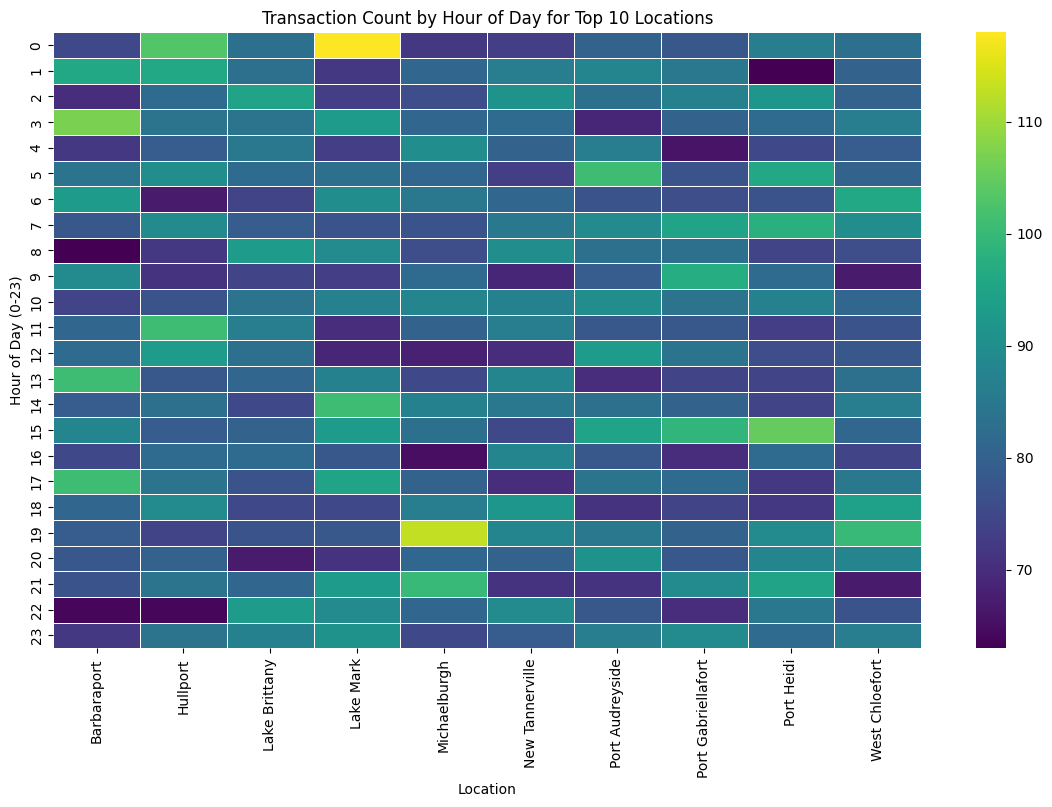


--- Performing Chi-square Test for Location vs. Hour of Day ---
Chi-square Statistic: 220.11
P-value: 0.253
Degrees of Freedom (dof): 207

--- Interpretation ---
Since the p-value (0.253) is greater than the significance level (0.05),
we fail to reject the null hypothesis.
Conclusion: There is no statistically significant association between 'Location' and 'Hour of Day'.
This means the pattern of transaction times is independent of the location (or we don't have enough evidence to say otherwise).

--- Activity distribution for 'Lake Mark' ---


C:\Users\souma\AppData\Local\Temp\ipykernel_42024\1814873455.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=location_time_df_filtered[location_time_df_filtered['Location'] == example_location],


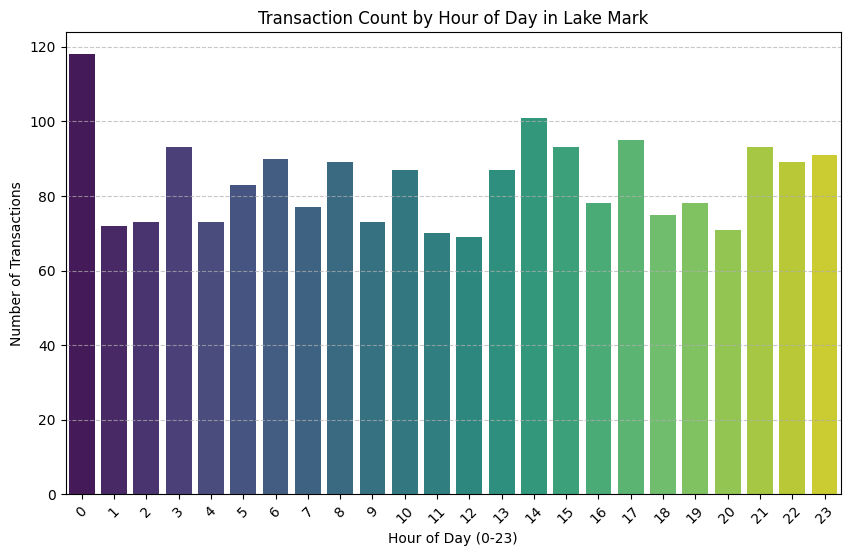

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Explpring the correlation between time and location

print("\n--- Top 10 Most Frequent Locations ---")
print(df['Location'].value_counts().head(10))

print("\n" + "="*50 + "\n")

# Analyzing Location activity by Hour of Day
# First, we need to clean the data for NaNs in 'Location' and 'Hour_Of_Day' if they exist, for this analysis
location_time_df = df.dropna(subset=['Location', 'Hour_Of_Day']).copy()
location_time_df['Hour_Of_Day'] = location_time_df['Hour_Of_Day'].astype(int) # hour needs to be an int

# Get top ten locations for clearer visualization 
top_locations = location_time_df['Location'].value_counts().head(10).index.tolist()
location_time_df_filtered = location_time_df[location_time_df['Location'].isin(top_locations)]

print(f"\n--- Cross-tabulation: Transactions by Hour of Day for Top {len(top_locations)} Locations ---")
# Create a pivot table to count transactions per hour per location
location_hour_counts = location_time_df_filtered.pivot_table(
    index='Hour_Of_Day',
    columns='Location',
    aggfunc='size', # number of occurrences
    fill_value=0
)
print(location_hour_counts)

print("\n" + "="*50 + "\n")

# --- Visualization: Heatmap of Location vs. Hour of Day ---
print("\n--- Visualizing Location Activity by Hour of Day ---")

plt.figure(figsize=(14, 8))
sns.heatmap(location_hour_counts, cmap='viridis', annot=False, fmt='d', linewidths=.5)
plt.title(f'Transaction Count by Hour of Day for Top {len(top_locations)} Locations')
plt.xlabel('Location')
plt.ylabel('Hour of Day (0-23)')
plt.show()

import scipy.stats as stats

# --- Perform Chi-square Test of Independence ---

print("\n--- Performing Chi-square Test for Location vs. Hour of Day ---")


# Perform the Chi-square test
chi2_statistic, p_value, dof, expected_frequencies = stats.chi2_contingency(location_hour_counts)

print(f"Chi-square Statistic: {chi2_statistic:.2f}")
print(f"P-value: {p_value:.3f}") # 
print(f"Degrees of Freedom (dof): {dof}")



# --- Interpret the Results ---

alpha = 0.05 # significance level ( if it is less than 0.5 then we reject the null hypthesiss, there is a correlation, else, fail to reject it)

print("\n--- Interpretation ---")
if p_value < alpha:
    print(f"Since the p-value ({p_value:.3f}) is less than the significance level ({alpha}),")
    print("we reject the null hypothesis.")
    print("Conclusion: There is a statistically significant association between 'Location' and 'Hour of Day'.")
    print("This means the pattern of transaction times is not independent of the location.")
else:
    print(f"Since the p-value ({p_value:.3f}) is greater than the significance level ({alpha}),")
    print("we fail to reject the null hypothesis.")
    print("Conclusion: There is no statistically significant association between 'Location' and 'Hour of Day'.")
    print("This means the pattern of transaction times is independent of the location (or we don't have enough evidence to say otherwise).")



    
# --- Deeper dive into specific location (example) ---
# since lake mark is the top most freuent locations, we will use it as the example
example_location = 'Lake Mark' 


print(f"\n--- Activity distribution for '{example_location}' ---")
plt.figure(figsize=(10, 6))
sns.countplot(data=location_time_df_filtered[location_time_df_filtered['Location'] == example_location],
x='Hour_Of_Day', palette='viridis')
plt.title(f'Transaction Count by Hour of Day in {example_location}')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
